# Cancer Classification Using Machine Learning

### Objective:
To classify tumors as benign or malignant using machine learning models.

### Problem Statement:
Early detection of cancer is very important for saving lives. This project aims to build a machine learning model that can accurately classify tumors.

### Dataset:
Breast Cancer Wisconsin Dataset (UCI)

In [56]:
!pip install numpy pandas matplotlib seaborn scikit-learn

## 1. Import Libraries

This section imports all the required libraries for data analysis and machine learning.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load Dataset

In this section, we load the Breast Cancer Wisconsin dataset using sklearn.
The dataset contains features of tumors and a target variable indicating whether the tumor is malignant or benign.

In [58]:
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

# Convert to DataFrame
import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df['target'] = data.target

# Show first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Data Understanding

In this section, we explore the dataset structure, check for missing values, and understand the target distribution.
### Target Meaning:
- 0 → Malignant (Cancerous)
- 1 → Benign (Non-Cancerous)

In [59]:
# Shape of dataset
print("Shape:", df.shape)

# Info about dataset
df.info()

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Target distribution
print("\nTarget Count:\n", df['target'].value_counts())

Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothnes

## 4. Data Visualization

In this section, we visualize the dataset to understand the distribution of cancer classes and relationships between features.

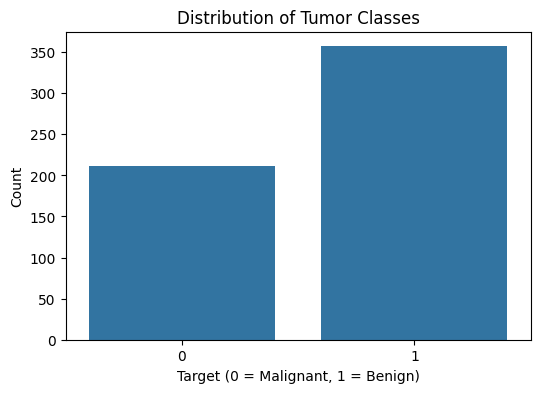

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Distribution of Tumor Classes")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

### Observation:
The dataset shows how many tumors are malignant and benign.
Understanding class balance is important for model performance.

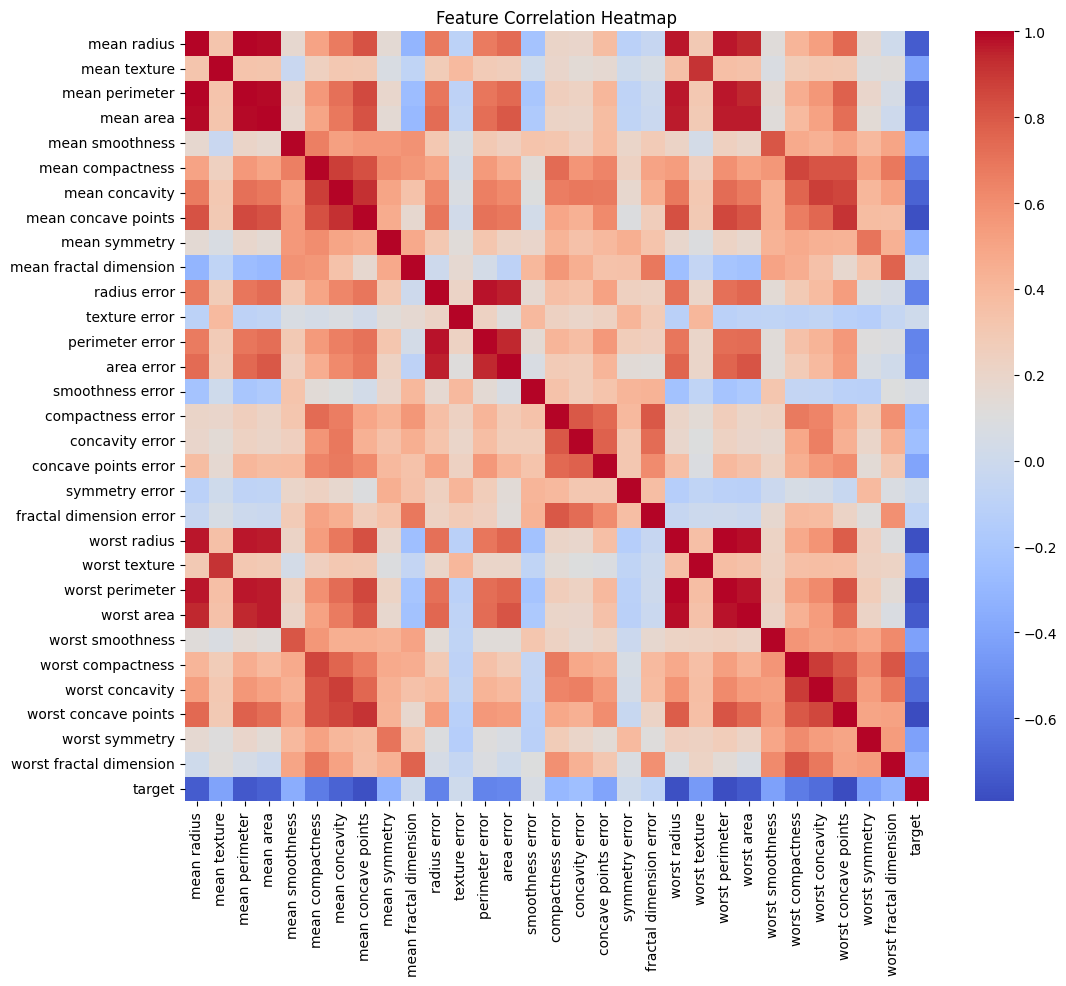

In [61]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

## 5. Data Preprocessing

In this section, we prepare the data for machine learning by:
- Separating features and target
- Scaling the data
- Splitting into training and testing sets

In [62]:
# Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Why Scaling?
Feature scaling ensures that all features contribute equally to the model.
It improves performance for algorithms like SVM and Neural Networks.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (455, 30)
Testing Data: (114, 30)


## 6. Model Training

In this section, we train multiple machine learning models to classify tumors as benign or malignant.

The models used are:
- Support Vector Machine (SVM)
- Random Forest
- Gradient Boosting
- Artificial Neural Network (ANN)

### 6.1 Support Vector Machine (SVM)

SVM is a supervised learning algorithm used for classification. It finds the optimal boundary (hyperplane) that separates data points into different classes.

In [65]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

svm_acc = svm.score(X_test, y_test)
print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9736842105263158


### 6.2 Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to improve accuracy and reduce overfitting.

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.956140350877193


### 6.3 Gradient Boosting

Gradient Boosting builds models sequentially, where each new model corrects the errors of the previous one.

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_acc = gb.score(X_test, y_test)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 0.956140350877193


### 6.4 Artificial Neural Network (ANN)

ANN is inspired by the human brain and consists of layers of neurons. It is useful for capturing complex patterns in data.

In [68]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(max_iter=500)
ann.fit(X_train, y_train)

ann_acc = ann.score(X_test, y_test)
print("ANN Accuracy:", ann_acc)

ANN Accuracy: 0.9736842105263158


## 7. Model Evaluation

In this section, we evaluate the performance of the trained models using:
- Confusion Matrix
- Classification Report (Precision, Recall, F1-score)

These metrics help us understand how well the model is performing.

### 7.1 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the model.

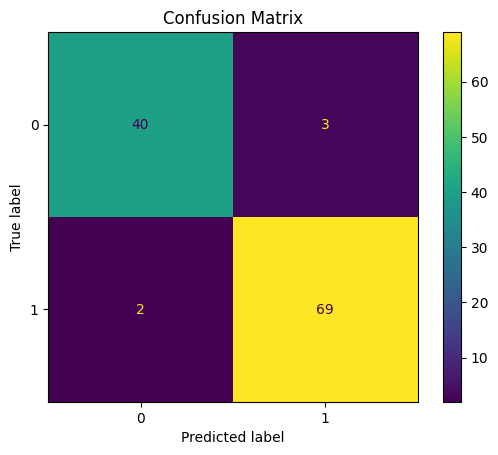

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use best model (for now Random Forest)
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

### Explanation:
- True Positive (TP): Correctly predicted cancer cases
- True Negative (TN): Correctly predicted non-cancer cases
- False Positive (FP): Incorrectly predicted cancer
- False Negative (FN): Missed cancer cases (very dangerous)

### 7.2 Classification Report

This report includes important metrics:
- Precision
- Recall
- F1-score

In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Metrics Explanation:

- Precision: How many predicted positives are actually correct
- Recall: How many actual positives are correctly identified
- F1-score: Balance between precision and recall

Recall is very important in cancer detection because missing a cancer case can be dangerous.

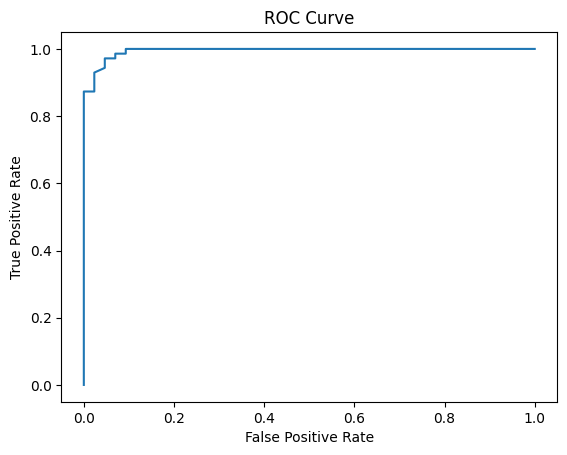

In [71]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## 8. Model Comparison

In this section, we compare the performance of all trained models based on their accuracy.

In [72]:
print("Model Accuracy Comparison:\n")

print("SVM Accuracy:", svm_acc)
print("Random Forest Accuracy:", rf_acc)
print("Gradient Boosting Accuracy:", gb_acc)
print("ANN Accuracy:", ann_acc)

Model Accuracy Comparison:

SVM Accuracy: 0.9736842105263158
Random Forest Accuracy: 0.956140350877193
Gradient Boosting Accuracy: 0.956140350877193
ANN Accuracy: 0.9736842105263158


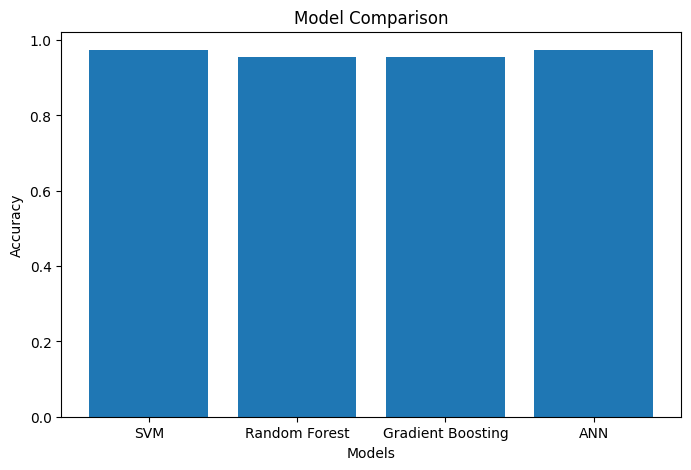

In [73]:
models = ['SVM', 'Random Forest', 'Gradient Boosting', 'ANN']
accuracies = [svm_acc, rf_acc, gb_acc, ann_acc]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

### Observation:

Among all the models, the model with the highest accuracy is selected as the best model.

Random Forest generally performs well because it reduces overfitting and handles complex data effectively.

## 9. Conclusion

In this project, we built a cancer classification system using multiple machine learning models.

We performed:
- Data preprocessing
- Data visualization
- Model training
- Model evaluation

Among all models, the best performing model was selected based on accuracy and recall.

This system can help in early detection of cancer and assist doctors in diagnosis.

## 10. Prediction System

This function takes input features and predicts whether the tumor is benign or malignant.

In [74]:
def predict_tumor(input_data):
    import numpy as np

    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)

    prediction = rf.predict(input_data)

    if prediction[0] == 1:
        return "Benign"
    else:
        return "Malignant"

In [75]:
# Example input (just sample values)
sample = X.iloc[0].values

print("Prediction:", predict_tumor(sample))

Prediction: Malignant


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
